 Analyses of Supply-Demand Factors Impacting U.S. Home Prices


 Two datasets are collected for this assignment :- 
1. Supply Data 
2. Demand Data

**These datasets contain quarterly data on key supply-demand factors that influence US home prices nationally in the last 20 years and are collected from Kaggle.**

In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score,KFold

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

**Loading the supply Dataset**

In [4]:
df_supply = pd.read_csv("supply.csv")
df_supply.head()

,DATE,CSUSHPISA,MSACSR,PERMIT,TLRESCONS,EVACANTUSQ176N
0,01-01-2003,129.321,4.2,1806.333333,421328.6667,14908
1,01-04-2003,131.756,3.833333333,1837.666667,429308.6667,15244
2,01-07-2003,135.013,3.633333333,1937.333333,458890,15614
3,01-10-2003,138.8356667,3.966666667,1972.333333,491437.3333,15654
4,01-01-2004,143.2986667,3.7,1994.666667,506856.3333,15895


1. CSUSHPISA :- S&P/Case-Shiller U.S. National Home Price Index (Index Jan 2000=100, Seasonally Adjusted)
2. MSACSR :- Monthly Supply of New Houses in the United States (Seasonally Adjusted)
3. PERMIT :- New Privately-Owned Housing Units Authorized in Permit-Issuing Places: Total Units (Thousands of Units, Seasonally Adjusted Annual Rate)
4. TLRESCONS :- Total Construction Spending: Residential in the United States (Millions of Dollars, Seasonally Adjusted Annual Rate)
5. EVACANTUSQ176N :- Housing Inventory Estimate: Vacant Housing Units in the United States (Thousands of Units, Not Seasonally Adjusted)

In [5]:
df_supply.shape

(82, 6)

In [6]:
df_supply.dtypes

DATE              object
CSUSHPISA         object
MSACSR            object
PERMIT            object
TLRESCONS         object
EVACANTUSQ176N    object
dtype: object

Preprocessing

In [7]:
df_supply['DATE'] = pd.to_datetime(df_supply['DATE']) 
df_supply['CSUSHPISA'] = pd.to_numeric(df_supply['CSUSHPISA'], errors='coerce')
df_supply['MSACSR'] = pd.to_numeric(df_supply['MSACSR'], errors='coerce')
df_supply['PERMIT'] = pd.to_numeric(df_supply['PERMIT'], errors='coerce')
df_supply['TLRESCONS'] = pd.to_numeric(df_supply['TLRESCONS'], errors='coerce')
df_supply['EVACANTUSQ176N'] = pd.to_numeric(df_supply['EVACANTUSQ176N'], errors='coerce')



In [8]:
df_supply.isna().sum()

DATE              0
CSUSHPISA         2
MSACSR            1
PERMIT            1
TLRESCONS         1
EVACANTUSQ176N    1
dtype: int64

**Handling the missing value in supply**

In [9]:
df_supply['CSUSHPISA'] = df_supply['CSUSHPISA'].fillna(df_supply['CSUSHPISA'].mean()) # filling the missing values with mean of the column
df_supply['MSACSR'] = df_supply['MSACSR'].fillna(df_supply['MSACSR'].mean())
df_supply['PERMIT'] = df_supply['PERMIT'].fillna(df_supply['PERMIT'].mean())
df_supply['TLRESCONS'] = df_supply['TLRESCONS'].fillna(df_supply['TLRESCONS'].mean())
df_supply['EVACANTUSQ176N'] = df_supply['EVACANTUSQ176N'].fillna(df_supply['EVACANTUSQ176N'].mean())

In [10]:
df_supply.isna().sum()

DATE              0
CSUSHPISA         0
MSACSR            0
PERMIT            0
TLRESCONS         0
EVACANTUSQ176N    0
dtype: int64

In [11]:
df_supply.head()

,DATE,CSUSHPISA,MSACSR,PERMIT,TLRESCONS,EVACANTUSQ176N
0,2003-01-01,129.321000,4.200000,1806.333333,421328.6667,14908.0
1,2003-01-04,131.756000,3.833333,1837.666667,429308.6667,15244.0
2,2003-01-07,135.013000,3.633333,1937.333333,458890.0000,15614.0
3,2003-01-10,138.835667,3.966667,1972.333333,491437.3333,15654.0
4,2004-01-01,143.298667,3.700000,1994.666667,506856.3333,15895.0


### Demand

In [12]:
df_demand = pd.read_csv("demand.csv")
df_demand.head()

,DATE,CSUSHPISA,MORTGAGE30US,UMCSENT,INTDSRUSM193N,MSPUS,GDP
0,01-01-2003,129.321000,5.840769,79.966667,2.250000,186000,11174.129
1,01-04-2003,131.756000,5.506923,89.266667,2.166667,191800,11312.766
2,01-07-2003,135.013000,6.033846,89.300000,2.000000,191900,11566.669
3,01-10-2003,138.835667,5.919286,91.966667,2.000000,198800,11772.234
4,01-01-2004,143.298667,5.597500,98.000000,2.000000,212700,11923.447


1. CSUSHPISA :- S&P/Case-Shiller U.S. National Home Price Index (Index Jan 2000=100, Seasonally Adjusted)
2. MORTGAGE15US :- 30-Year Fixed Rate Mortgage Average in the United States (Percent, Not Seasonally Adjusted)
3. UMCSENT :- 	University of Michigan: Consumer Sentiment
4. INTDSRUSM193N :-	Interest Rates, Discount Rate for United States (Billions of Dollars, Seasonally Adjusted Annual Rate)
5. MSPUS :-	Median Sales Price of Houses Sold for the United States (Not Seasonally Adjusted)
6. GDP	:- Gross Domestic Product (Billions of Dollars, Seasonally Adjusted Annual Rate)



In [13]:
df_demand.shape

(81, 7)

In [14]:
df_demand.dtypes

DATE              object
CSUSHPISA        float64
MORTGAGE30US     float64
UMCSENT          float64
INTDSRUSM193N    float64
MSPUS              int64
GDP              float64
dtype: object

In [15]:
df_demand['DATE'] = pd.to_datetime(df_demand['DATE'])
df_demand.dtypes

DATE             datetime64[ns]
CSUSHPISA               float64
MORTGAGE30US            float64
UMCSENT                 float64
INTDSRUSM193N           float64
MSPUS                     int64
GDP                     float64
dtype: object

In [16]:
df_demand.isna().sum()

DATE             0
CSUSHPISA        1
MORTGAGE30US     0
UMCSENT          0
INTDSRUSM193N    7
MSPUS            0
GDP              0
dtype: int64

### Handling the missing value in demand

In [17]:
imputer = SimpleImputer(strategy='mean')
df_demand['INTDSRUSM193N'] = imputer.fit_transform(df_demand[['INTDSRUSM193N']])

df_demand['CSUSHPISA'] = df_demand['CSUSHPISA'].fillna(df_demand['CSUSHPISA'].mean())

In [18]:
df_demand.isna().sum()

DATE             0
CSUSHPISA        0
MORTGAGE30US     0
UMCSENT          0
INTDSRUSM193N    0
MSPUS            0
GDP              0
dtype: int64

In [19]:
df_demand.tail()

,DATE,CSUSHPISA,MORTGAGE30US,UMCSENT,INTDSRUSM193N,MSPUS,GDP
76,2022-01-01,290.868000,3.822308,63.133333,1.961712,433100,24740.480
77,2022-01-04,303.422667,5.266154,57.866667,1.961712,449300,25248.476
78,2022-01-07,301.726333,5.623077,56.100000,1.961712,468000,25723.941
79,2022-01-10,297.896667,6.664615,58.800000,1.961712,479500,26137.992
80,2023-01-01,180.658712,6.372308,64.633333,1.961712,436800,26465.865


## Merging the demand and supply data

In [20]:
df_supply = df_supply.sort_values('DATE')
df_demand = df_demand.sort_values('DATE')

In [21]:
df_merged = pd.merge(df_supply, df_demand, on='DATE')

In [22]:
df_merged.head()

,DATE,CSUSHPISA_x,MSACSR,PERMIT,TLRESCONS,EVACANTUSQ176N,CSUSHPISA_y,MORTGAGE30US,UMCSENT,INTDSRUSM193N,MSPUS,GDP
0,2003-01-01,129.321000,4.200000,1806.333333,421328.6667,14908.0,129.321000,5.840769,79.966667,2.250000,186000,11174.129
1,2003-01-04,131.756000,3.833333,1837.666667,429308.6667,15244.0,131.756000,5.506923,89.266667,2.166667,191800,11312.766
2,2003-01-07,135.013000,3.633333,1937.333333,458890.0000,15614.0,135.013000,6.033846,89.300000,2.000000,191900,11566.669
3,2003-01-10,138.835667,3.966667,1972.333333,491437.3333,15654.0,138.835667,5.919286,91.966667,2.000000,198800,11772.234
4,2004-01-01,143.298667,3.700000,1994.666667,506856.3333,15895.0,143.298667,5.597500,98.000000,2.000000,212700,11923.447


In [23]:
df_merged.drop('CSUSHPISA_y', axis=1, inplace=True) # dropping the duplicate column

In [24]:
df_merged.rename(columns={'CSUSHPISA_x': 'CSUSHPISA'}, inplace=True)
# renaming the column to original name

In [25]:
df_merged.head()

,DATE,CSUSHPISA,MSACSR,PERMIT,TLRESCONS,EVACANTUSQ176N,MORTGAGE30US,UMCSENT,INTDSRUSM193N,MSPUS,GDP
0,2003-01-01,129.321000,4.200000,1806.333333,421328.6667,14908.0,5.840769,79.966667,2.250000,186000,11174.129
1,2003-01-04,131.756000,3.833333,1837.666667,429308.6667,15244.0,5.506923,89.266667,2.166667,191800,11312.766
2,2003-01-07,135.013000,3.633333,1937.333333,458890.0000,15614.0,6.033846,89.300000,2.000000,191900,11566.669
3,2003-01-10,138.835667,3.966667,1972.333333,491437.3333,15654.0,5.919286,91.966667,2.000000,198800,11772.234
4,2004-01-01,143.298667,3.700000,1994.666667,506856.3333,15895.0,5.597500,98.000000,2.000000,212700,11923.447


In [26]:
df_merged.dtypes

DATE              datetime64[ns]
CSUSHPISA                float64
MSACSR                   float64
PERMIT                   float64
TLRESCONS                float64
EVACANTUSQ176N           float64
MORTGAGE30US             float64
UMCSENT                  float64
INTDSRUSM193N            float64
MSPUS                      int64
GDP                      float64
dtype: object

### Changing the name of colums for better understanding


In [31]:
df_merged.rename(columns={'CSUSHPISA':'National_home_price_index','MSACSR':'Monthly_supply','PERMIT':'Permit_issued','TLRESCONS':'Total_construction_spending'\
                  ,'EVACANTUSQ176N':'Housing_inventory_estimate','MORTGAGE30US':'30y_fixed_mortgage_rate','UMCSENT':'Consumer_sentiment','INTDSRUSM193N':'Interest_rates'\
                  ,'MSPUS':'Median_sales_price','DATE':'Date'},inplace = True)

In [32]:
df_merged.head()

,Date,National_home_price_index,Monthly_supply,Permit_issued,Total_construction_spending,Housing_inventory_estimate,30y_fixed_mortgage_rate,Consumer_sentiment,Interest_rates,Median_sales_price,GDP
0,2003-01-01,129.321000,4.200000,1806.333333,421328.6667,14908.0,5.840769,79.966667,2.250000,186000,11174.129
1,2003-01-04,131.756000,3.833333,1837.666667,429308.6667,15244.0,5.506923,89.266667,2.166667,191800,11312.766
2,2003-01-07,135.013000,3.633333,1937.333333,458890.0000,15614.0,6.033846,89.300000,2.000000,191900,11566.669
3,2003-01-10,138.835667,3.966667,1972.333333,491437.3333,15654.0,5.919286,91.966667,2.000000,198800,11772.234
4,2004-01-01,143.298667,3.700000,1994.666667,506856.3333,15895.0,5.597500,98.000000,2.000000,212700,11923.447


## Exploratory Data Analysis

### Plotting the data

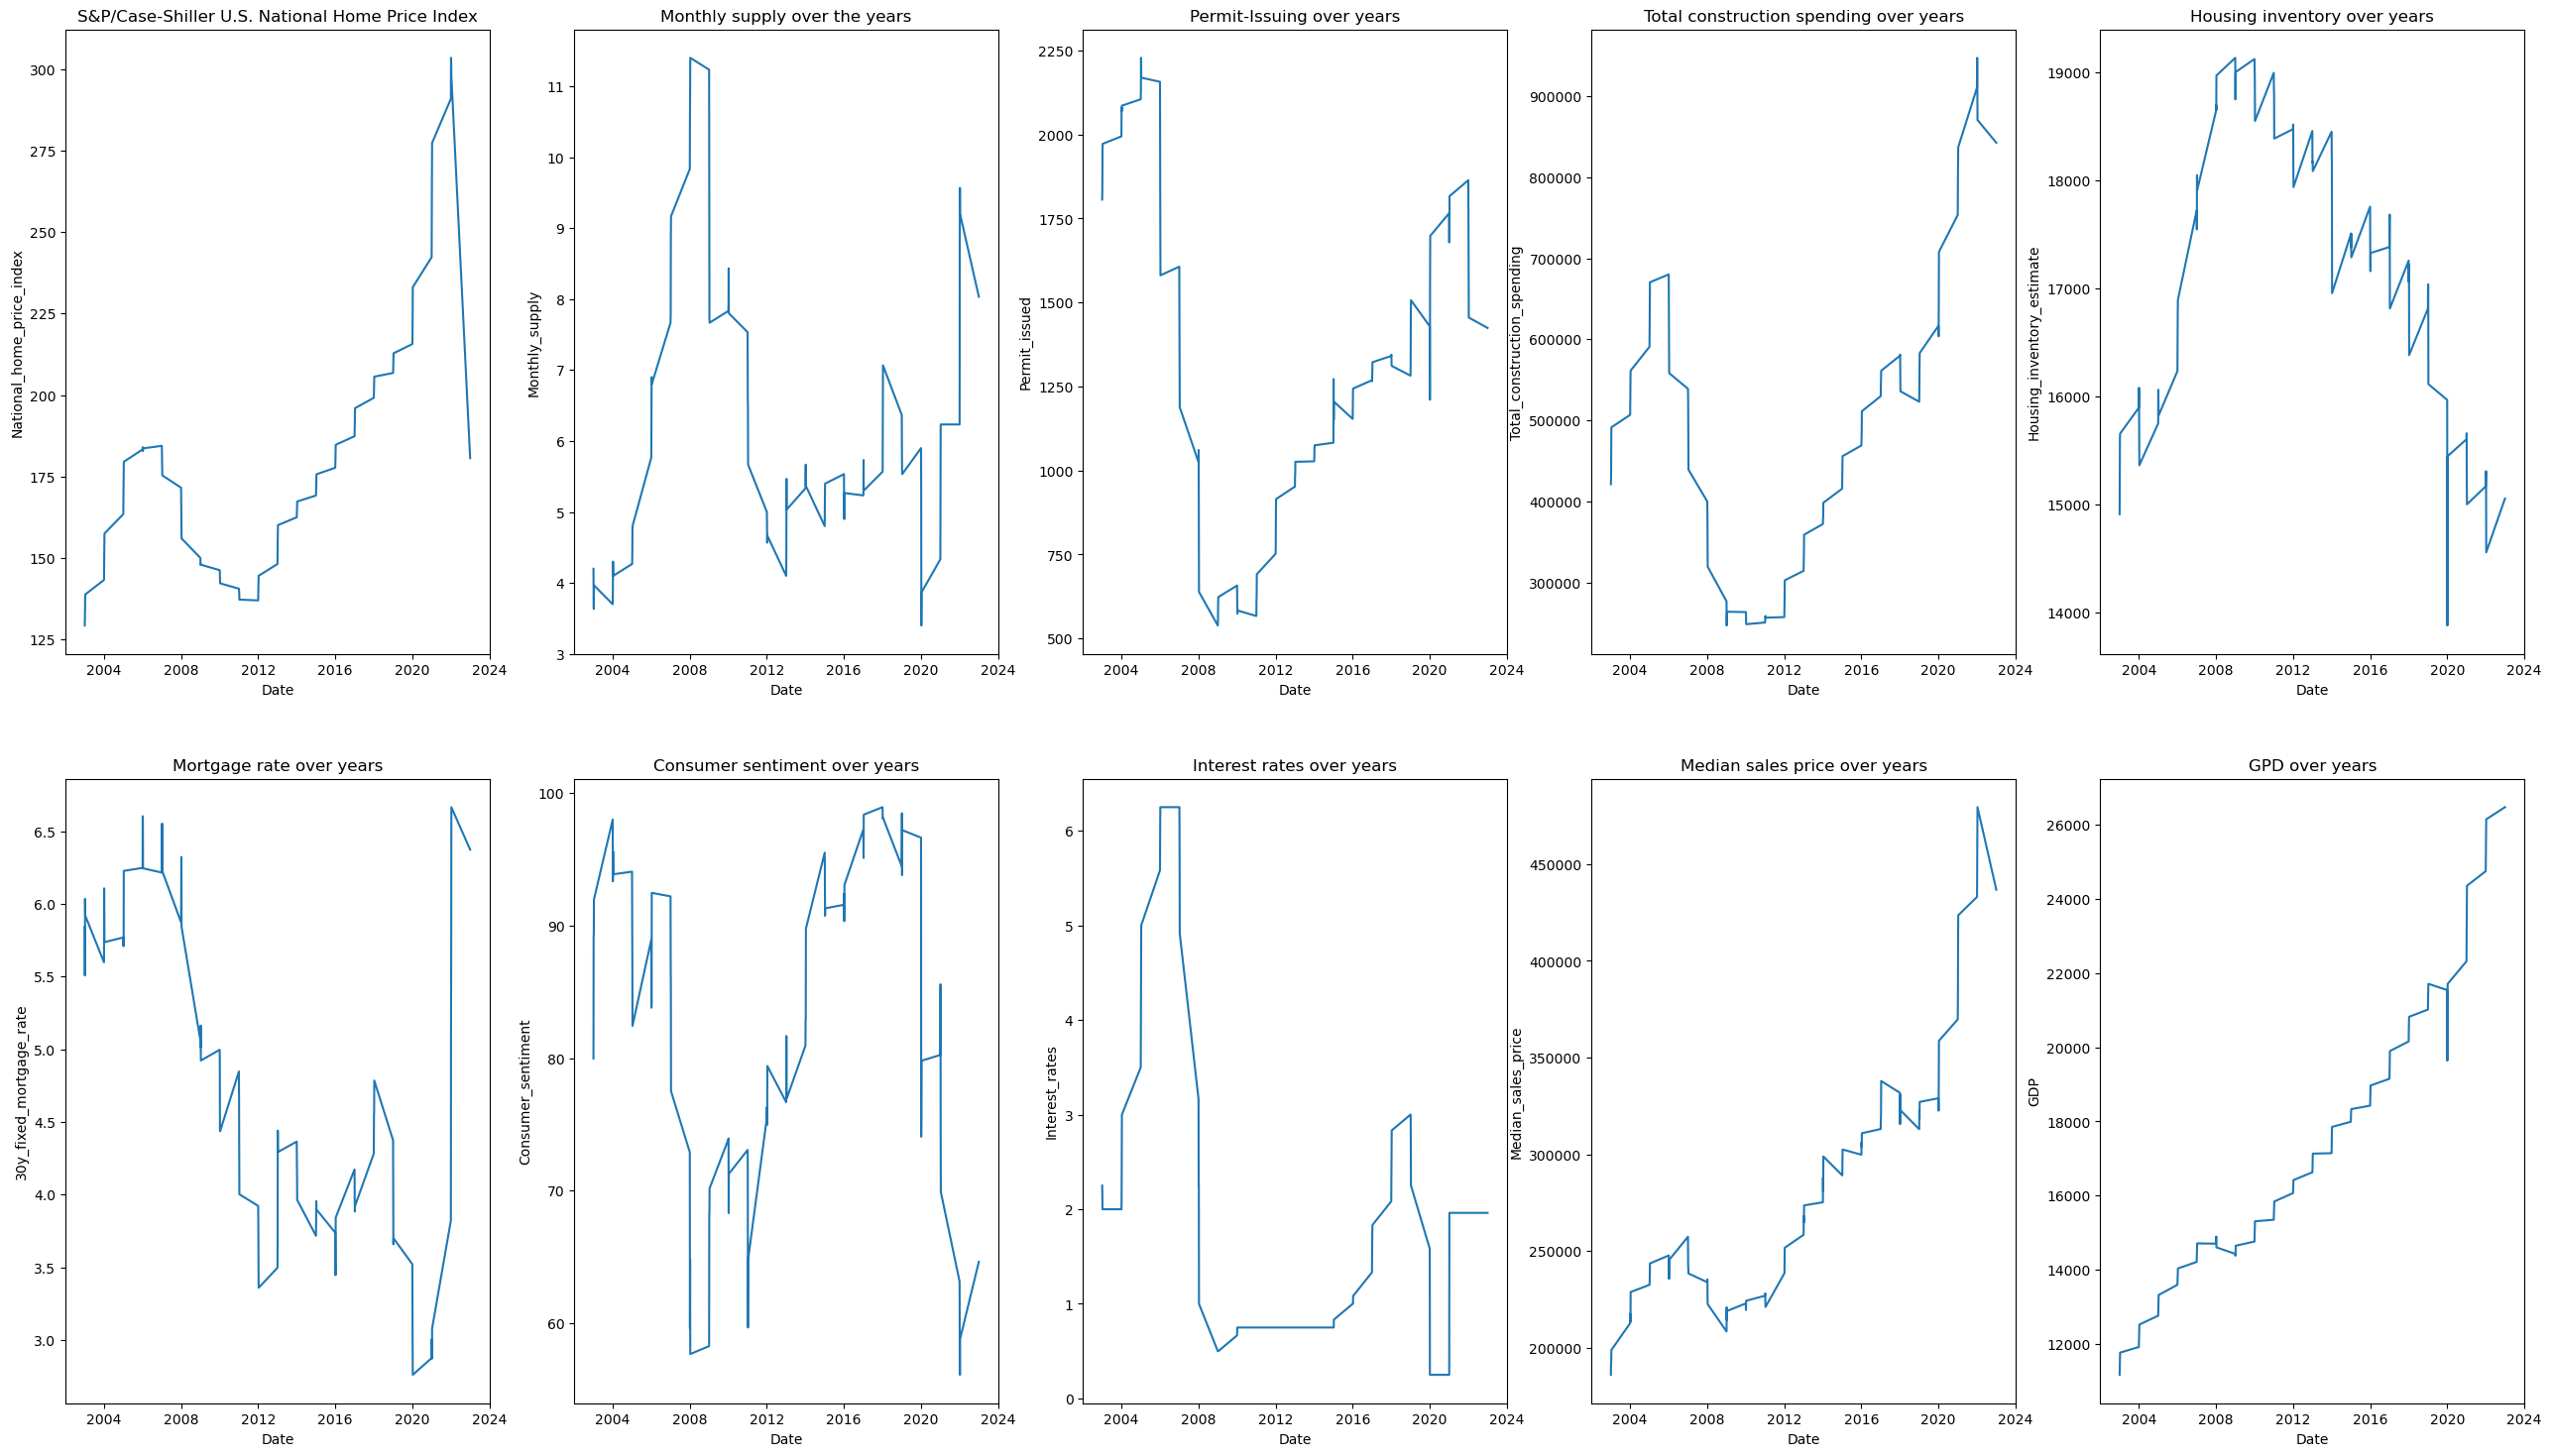

In [33]:
figure,ax = plt.subplots(nrows = 2,ncols = 5,figsize=(32,18))

sns.lineplot(ax = ax[0,0],x='Date',y='National_home_price_index',data = df_merged);
sns.lineplot(ax = ax[0,1],x='Date',y='Monthly_supply',data = df_merged);
sns.lineplot(ax = ax[0,2],x='Date',y='Permit_issued',data = df_merged);
sns.lineplot(ax = ax[0,3],x='Date',y='Total_construction_spending',data = df_merged);
sns.lineplot(ax = ax[0,4],x='Date',y='Housing_inventory_estimate',data = df_merged);
sns.lineplot(ax = ax[1,0],x='Date',y='30y_fixed_mortgage_rate',data = df_merged);

sns.lineplot(ax = ax[1,1],x='Date',y='Consumer_sentiment',data = df_merged);
sns.lineplot(ax = ax[1,2],x='Date',y='Interest_rates',data =df_merged);
sns.lineplot(ax = ax[1,3],x='Date',y='Median_sales_price',data =df_merged);
sns.lineplot(ax = ax[1,4],x='Date',y='GDP',data = df_merged);

ax[0,0].title.set_text('S&P/Case-Shiller U.S. National Home Price Index')
ax[0,1].title.set_text('Monthly supply over the years')
ax[0,2].title.set_text('Permit-Issuing over years')
ax[0,3].title.set_text('Total construction spending over years')
ax[0,4].title.set_text('Housing inventory over years')
ax[1,0].title.set_text('Mortgage rate over years')
ax[1,1].title.set_text('Consumer sentiment over years')
ax[1,2].title.set_text('Interest rates over years')
ax[1,3].title.set_text('Median sales price over years')
ax[1,4].title.set_text('GPD over years')


### Correlation Heatmap

In [34]:
### Correlation Heatmap